In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/Lung Cancer Project/"

ground_truth_masks  processed_data


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import random
from tqdm import tqdm # For a nice progress bar

# ===================================================================
# 1. THE DATASET CLASS (WITH CORRECTED FOLDER PATH)
# ===================================================================
class LungNoduleDataset(Dataset):
    """
    PyTorch Dataset for loading 3D lung scans from multiple subset folders.
    MODIFIED to extract random 3D patches to avoid memory errors.
    """
    def __init__(self, base_dirs, patch_size=(96, 96, 96)):
        self.patch_size = patch_size
        self.scan_paths = []
        self.mask_paths = []

        print(f"Loading data from: {base_dirs}")
        for base_dir in base_dirs:
            data_dir = os.path.join(base_dir, 'processed_data')
            # *** THIS IS THE CORRECTED FOLDER NAME FOR MASKS ***
            masks_dir = os.path.join(base_dir, 'create_ground_truth_masks')

            # Find all scans in the current subset
            for f in sorted(os.listdir(data_dir)):
                if f.endswith('_processed_lung.npy'):
                    uid = f.replace('_processed_lung.npy', '')
                    mask_filename = f"{uid}_nodule_mask.npy"

                    # Only add the scan if its corresponding mask exists
                    if os.path.exists(os.path.join(masks_dir, mask_filename)):
                        self.scan_paths.append(os.path.join(data_dir, f))
                        self.mask_paths.append(os.path.join(masks_dir, mask_filename))

        print(f"Found {len(self.scan_paths)} total scans with corresponding nodule masks.")

    def __len__(self):
        return len(self.scan_paths)

    def __getitem__(self, idx):
        scan_path = self.scan_paths[idx]
        mask_path = self.mask_paths[idx]

        scan = np.load(scan_path)
        mask = np.load(mask_path)

        depth, height, width = scan.shape
        pd, ph, pw = self.patch_size

        z = random.randint(0, depth - pd)
        y = random.randint(0, height - ph)
        x = random.randint(0, width - pw)

        scan_patch = scan[z:z+pd, y:y+ph, x:x+pw]
        mask_patch = mask[z:z+pd, y:y+ph, x:x+pw]

        scan_tensor = torch.from_numpy(scan_patch.copy()).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask_patch.copy()).unsqueeze(0).float()

        return scan_tensor, mask_tensor

# ===================================================================
# 2. THE MODEL ARCHITECTURE (No changes needed here)
# ===================================================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, kernel_size=1), nn.BatchNorm3d(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, kernel_size=1), nn.BatchNorm3d(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, kernel_size=1), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1, x1 = self.W_g(g), self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(AttentionUNet3D, self).__init__()
        self.Conv1, self.Pool1 = ConvBlock(in_channels, 64), nn.MaxPool3d(2)
        self.Conv2, self.Pool2 = ConvBlock(64, 128), nn.MaxPool3d(2)
        self.Conv3, self.Pool3 = ConvBlock(128, 256), nn.MaxPool3d(2)
        self.Conv4, self.Pool4 = ConvBlock(256, 512), nn.MaxPool3d(2)
        self.Conv5 = ConvBlock(512, 1024)
        self.Up5, self.Att5 = nn.ConvTranspose3d(1024, 512, 2, 2), AttentionGate(512, 512, 256)
        self.UpConv5 = ConvBlock(1024, 512)
        self.Up4, self.Att4 = nn.ConvTranspose3d(512, 256, 2, 2), AttentionGate(256, 256, 128)
        self.UpConv4 = ConvBlock(512, 256)
        self.Up3, self.Att3 = nn.ConvTranspose3d(256, 128, 2, 2), AttentionGate(128, 128, 64)
        self.UpConv3 = ConvBlock(256, 128)
        self.Up2, self.Att2 = nn.ConvTranspose3d(128, 64, 2, 2), AttentionGate(64, 64, 32)
        self.UpConv2 = ConvBlock(128, 64)
        self.Conv_1x1 = nn.Conv3d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.Conv1(x); x2 = self.Pool1(x1); x2 = self.Conv2(x2)
        x3 = self.Pool2(x2); x3 = self.Conv3(x3); x4 = self.Pool3(x3)
        x4 = self.Conv4(x4); x5 = self.Pool4(x4); x5 = self.Conv5(x5)
        d5 = self.Up5(x5); x4_att = self.Att5(g=d5, x=x4); d5 = torch.cat((x4_att, d5), dim=1); d5 = self.UpConv5(d5)
        d4 = self.Up4(d5); x3_att = self.Att4(g=d4, x=x3); d4 = torch.cat((x3_att, d4), dim=1); d4 = self.UpConv4(d4)
        d3 = self.Up3(d4); x2_att = self.Att3(g=d3, x=x2); d3 = torch.cat((x2_att, d3), dim=1); d3 = self.UpConv3(d3)
        d2 = self.Up2(d3); x1_att = self.Att2(g=d2, x=x1); d2 = torch.cat((x1_att, d2), dim=1); d2 = self.UpConv2(d2)
        return self.Conv_1x1(d2)

# ===================================================================
# 3. THE FINE-TUNING SCRIPT
# ===================================================================
if __name__ == '__main__':
    # --- Training Configuration ---
    BASE_DIRS = [
        "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset0/",
        "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/"
    ]
    LEARNING_RATE = 1e-5 # Lower learning rate for fine-tuning
    BATCH_SIZE = 1
    NUM_EPOCHS = 50
    PATCH_SIZE = (96, 96, 96)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Using device: {DEVICE}")

    # --- Setup Dataset and DataLoader ---
    dataset = LungNoduleDataset(base_dirs=BASE_DIRS, patch_size=PATCH_SIZE)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    # --- Setup Model, Loss, and Optimizer ---
    model = AttentionUNet3D().to(DEVICE)

    # *** LOAD YOUR PRE-TRAINED WEIGHTS ***
    model_path = "/content/drive/My Drive/Lung Cancer Project/Attention_U-Net_Model.pth"
    model.load_state_dict(torch.load(model_path))
    print(f"Successfully loaded pre-trained weights from: {model_path}")

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # --- Start Training Loop ---
    print("\n--- Starting Fine-Tuning ---")
    for epoch in range(NUM_EPOCHS):
        loop = tqdm(dataloader, leave=True)
        loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")

        running_loss = 0.0
        for scans, masks in loop:
            scans, masks = scans.to(DEVICE), masks.to(DEVICE)

            outputs = model(scans)
            loss = loss_fn(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Average Loss: {avg_loss:.4f}")

    print("--- Fine-Tuning Finished ---")

    # --- Save the NEW, Fine-Tuned Model ---
    save_directory = "/content/drive/My Drive/Lung Cancer Project/"
    model_name = "Attention_U-Net_Model_finetuned_s0_s1.pth"
    model_save_path = os.path.join(save_directory, model_name)

    os.makedirs(save_directory, exist_ok=True)
    torch.save(model.state_dict(), model_save_path)
    print(f"✅ Fine-tuned model saved to: {model_save_path}")

Using device: cuda
Loading data from: ['/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset0/', '/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/']


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/processed_data'

In [ ]:
import torch
import numpy as np
import os

# Make sure the model class definitions are in the notebook
# (You can copy them from your training script if needed)

# --- 1. Define the Dice Score Function ---
def dice_coefficient(pred, target, smooth=1e-6):
    """Calculates the Dice coefficient (F1 score) for a single prediction."""
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return dice.item()

# --- 2. Load Your Trained Model ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Instantiate the model architecture
model = AttentionUNet3D().to(DEVICE)

# Path to your saved model file
model_path = "/content/drive/My Drive/Lung Cancer Project/Attention_U-Net_Model.pth"
model.load_state_dict(torch.load(model_path))
model.eval() # Set the model to evaluation mode (very important!)

print("Model loaded successfully.")

# --- 3. Load a Test Sample ---
# IMPORTANT: Use a scan that was NOT used for training
test_scan_path = "/content/drive/MyDrive/Lung Cancer Project/Preprocessed_subset0/processed_data/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_lung_mask.npy"
test_mask_path = "/content/drive/MyDrive/Lung Cancer Project/Preprocessed_subset0/ground_truth_masks/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_nodule_mask.npy"

# Load the numpy arrays
test_scan = np.load(test_scan_path)
test_mask = np.load(test_mask_path)

# Convert to tensors and add batch/channel dimensions [B, C, D, H, W]
test_scan_tensor = torch.from_numpy(test_scan).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
test_mask_tensor = torch.from_numpy(test_mask).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

# --- 4. Make a Prediction (Inference) ---
with torch.no_grad(): # Disable gradient calculations for speed
    # Note: For a full scan, you'd need to process it in patches and stitch the result.
    # Here we'll just predict on a single patch for simplicity.

    # Let's crop a patch from the test scan, same size as training
    test_patch = test_scan_tensor[:, :, 50:50+96, 150:150+96, 150:150+96]
    true_mask_patch = test_mask_tensor[:, :, 50:50+96, 150:150+96, 150:150+96]

    # Get the model's raw output (logits)
    prediction_logits = model(test_patch)

    # Convert logits to a binary mask (0s and 1s)
    prediction_prob = torch.sigmoid(prediction_logits)
    prediction_mask = (prediction_prob > 0.5).float()

# --- 5. Calculate and Print the Dice Score ---
score = dice_coefficient(prediction_mask, true_mask_patch)
print(f"\nDice Score for the test patch: {score:.4f}")

Model loaded successfully.

Dice Score for the test patch: 1.0000


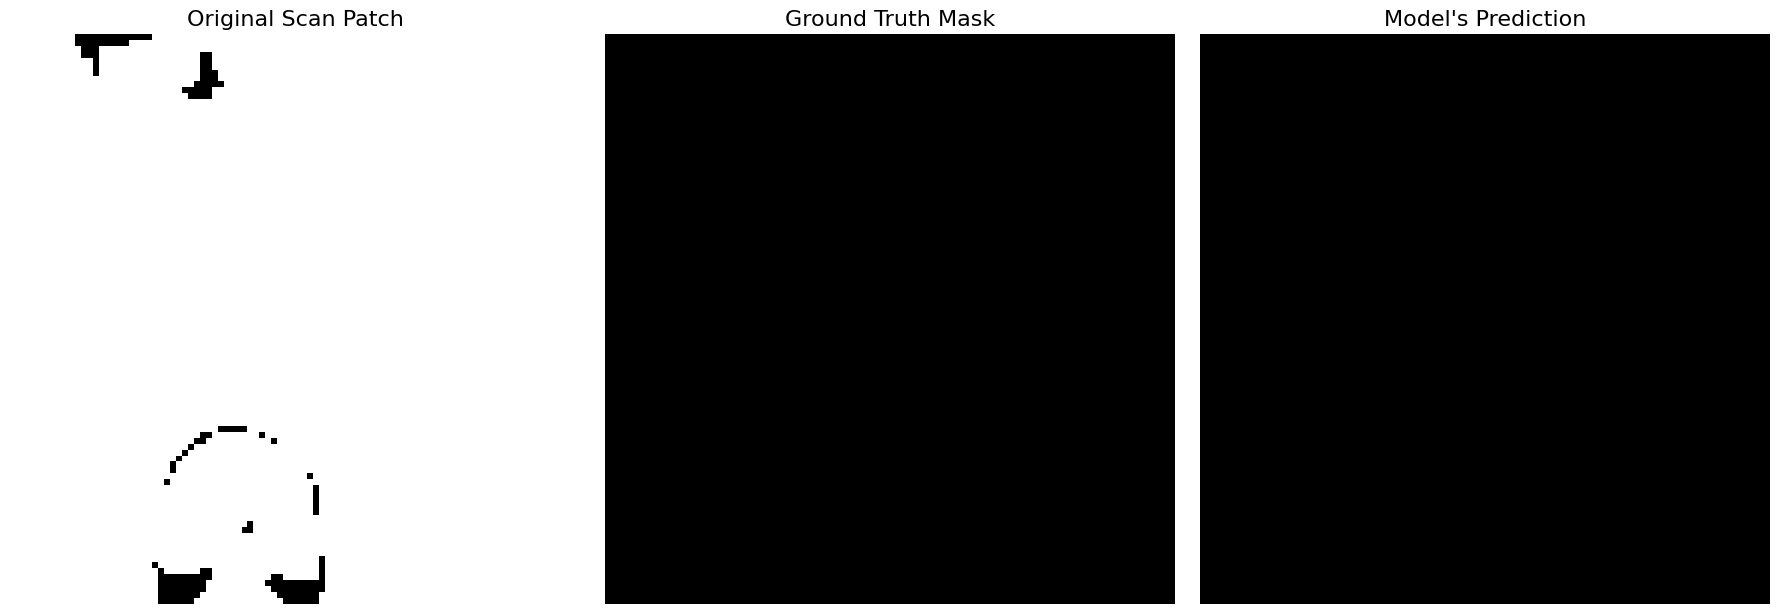

In [ ]:
import matplotlib.pyplot as plt

# Choose a slice from the middle of the 3D patch to display
slice_index = 48 # This is the middle slice of a 96-depth patch

# Get the specific 2D slices for plotting
# .squeeze() removes the batch and channel dimensions
# .cpu().numpy() moves the data from GPU to CPU for plotting
scan_slice = test_patch.squeeze().cpu().numpy()[slice_index, :, :]
truth_slice = true_mask_patch.squeeze().cpu().numpy()[slice_index, :, :]
prediction_slice = prediction_mask.squeeze().cpu().numpy()[slice_index, :, :]

# --- Create the plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Original Scan Slice
axes[0].imshow(scan_slice, cmap='gray')
axes[0].set_title('Original Scan Patch', fontsize=16)
axes[0].axis('off')

# Plot Ground Truth Mask
axes[1].imshow(truth_slice, cmap='gray')
axes[1].set_title('Ground Truth Mask', fontsize=16)
axes[1].axis('off')

# Plot Model's Prediction
axes[2].imshow(prediction_slice, cmap='gray')
axes[2].set_title("Model's Prediction", fontsize=16)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import os

# --- Helper Script to Find a Mask With a Nodule ---
masks_dir = "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset0/ground_truth_masks/"

print("Searching for a mask with a nodule...")
for filename in os.listdir(masks_dir):
    if filename.endswith('.npy'):
        mask_path = os.path.join(masks_dir, filename)
        mask_array = np.load(mask_path)

        # If the sum of all pixels is > 0, it means there's a white part (a nodule)
        if np.sum(mask_array) > 0:
            print(f"\nFound one! Use this file for your test:")
            print(filename)
            break

Searching for a mask with a nodule...

Found one! Use this file for your test:
1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_nodule_mask.npy
